<a href="https://colab.research.google.com/github/sairiamu/ML-DL-collection/blob/main/diffusion_iamgegen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Diffusion with MNIST, ###
`image gen `

In [1]:
!pip install -q torch torchvision matplotlib numpy

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np


In [16]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

IMAGE_SIZE = 32
T = 300                 # number of diffusion timesteps
EMB_DIM = 32             # combined time/text embedding dimension
BATCH_SIZE = 128
EPOCHS = 30
LR = 2e-4


Using device: cuda


In [17]:
WORD_TO_DIGIT = {
    "zero": 0, "one": 1, "two": 2, "three": 3, "four": 4,
    "five": 5, "six": 6, "seven": 7, "eight": 8, "nine": 9,
}
DIGIT_TO_WORD = {v: k for k, v in WORD_TO_DIGIT.items()}


In [18]:
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

print(f"Dataset size: {len(train_dataset)} images")


Dataset size: 60000 images


In [19]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        scale = math.log(10000) / (half_dim - 1)
        freqs = torch.exp(torch.arange(half_dim, device=device).float() * -scale)
        args = t[:, None].float() * freqs[None, :]
        emb = torch.cat((args.sin(), args.cos()), dim=-1)
        return emb

In [20]:
class CondBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.act = nn.SiLU()

    def forward(self, x, emb):
        h = self.act(self.bn1(self.conv1(x)))
        emb_out = self.emb_proj(emb)[:, :, None, None]
        h = h + emb_out
        h = self.act(self.bn2(self.conv2(h)))
        return h

In [21]:
class TinyTextUNet(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, num_classes=10):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )
        self.text_emb = nn.Embedding(num_classes, emb_dim)

        # Encoder
        self.down1 = CondBlock(1, 16, emb_dim)     # 32x32x16
        self.pool1 = nn.MaxPool2d(2)               # -> 16x16
        self.down2 = CondBlock(16, 32, emb_dim)    # 16x16x32
        self.pool2 = nn.MaxPool2d(2)               # -> 8x8

        # Bottleneck
        self.bottleneck = CondBlock(32, 64, emb_dim)  # 8x8x64

        # Decoder
        self.up_conv1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)  # 8x8 -> 16x16
        self.up_block1 = CondBlock(64, 32, emb_dim)  # concat with down2 (32) -> 64 in

        self.up_conv2 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)  # 16x16 -> 32x32
        self.up_block2 = CondBlock(32, 16, emb_dim)  # concat with down1 (16) -> 32 in

        self.out_conv = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x, t, text_idx):
        t_emb = self.time_mlp(t)
        c_emb = self.text_emb(text_idx)
        emb = t_emb + c_emb

        d1 = self.down1(x, emb)
        x2 = self.pool1(d1)
        d2 = self.down2(x2, emb)
        x3 = self.pool2(d2)

        b = self.bottleneck(x3, emb)

        u1 = self.up_conv1(b)
        u1 = torch.cat([u1, d2], dim=1)
        u1 = self.up_block1(u1, emb)

        u2 = self.up_conv2(u1)
        u2 = torch.cat([u2, d1], dim=1)
        u2 = self.up_block2(u2, emb)

        return self.out_conv(u2)

model = TinyTextUNet().to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameter count: {num_params:,} (target: under 500,000)")



Model parameter count: 125,105 (target: under 500,000)


In [22]:

# ---------------------------------------------------------------------------
# 6. DDPM noise schedule
# ---------------------------------------------------------------------------
betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

def q_sample(x0, t, noise):
    """Forward diffusion: sample x_t given x_0 and timestep t."""
    sac = sqrt_alphas_cumprod[t][:, None, None, None]
    somac = sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
    return sac * x0 + somac * noise

In [23]:
# ---------------------------------------------------------------------------
# 7. Training loop
# ---------------------------------------------------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print("\nStarting training...")
model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    num_batches = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        t = torch.randint(0, T, (images.shape[0],), device=device).long()
        noise = torch.randn_like(images)
        x_t = q_sample(images, t, noise)

        predicted_noise = model(x_t, t, labels)
        loss = F.mse_loss(predicted_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    print(f"Epoch [{epoch + 1}/{EPOCHS}] - Average Loss: {avg_loss:.6f}")

print("Training complete.\n")


Starting training...
Epoch [1/30] - Average Loss: 0.209061
Epoch [2/30] - Average Loss: 0.074982
Epoch [3/30] - Average Loss: 0.063430
Epoch [4/30] - Average Loss: 0.057894
Epoch [5/30] - Average Loss: 0.054966
Epoch [6/30] - Average Loss: 0.053224
Epoch [7/30] - Average Loss: 0.050335
Epoch [8/30] - Average Loss: 0.048441
Epoch [9/30] - Average Loss: 0.047819
Epoch [10/30] - Average Loss: 0.046344
Epoch [11/30] - Average Loss: 0.046167
Epoch [12/30] - Average Loss: 0.044924
Epoch [13/30] - Average Loss: 0.043958
Epoch [14/30] - Average Loss: 0.043190
Epoch [15/30] - Average Loss: 0.043324
Epoch [16/30] - Average Loss: 0.042175
Epoch [17/30] - Average Loss: 0.041702
Epoch [18/30] - Average Loss: 0.041279
Epoch [19/30] - Average Loss: 0.040492
Epoch [20/30] - Average Loss: 0.040458
Epoch [21/30] - Average Loss: 0.040097
Epoch [22/30] - Average Loss: 0.039427
Epoch [23/30] - Average Loss: 0.039154
Epoch [24/30] - Average Loss: 0.038800
Epoch [25/30] - Average Loss: 0.038820
Epoch [26/30

In [12]:

# ---------------------------------------------------------------------------
# 8. Reverse diffusion sampling
# ---------------------------------------------------------------------------
@torch.no_grad()
def sample(model, text_idx_tensor, image_size=IMAGE_SIZE, channels=1):
    model.eval()
    batch_size = text_idx_tensor.shape[0]
    x = torch.randn(batch_size, channels, image_size, image_size, device=device)

    for i in reversed(range(T)):
        t = torch.full((batch_size,), i, device=device, dtype=torch.long)
        predicted_noise = model(x, t, text_idx_tensor)

        alpha = alphas[i]
        alpha_cumprod = alphas_cumprod[i]
        beta = betas[i]

        if i > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1.0 / torch.sqrt(alpha)) * (
            x - ((1.0 - alpha) / torch.sqrt(1.0 - alpha_cumprod)) * predicted_noise
        ) + torch.sqrt(beta) * noise

    model.train()
    return x

In [13]:
# ---------------------------------------------------------------------------
# 9. Inference function: generate an image from a text label
# ---------------------------------------------------------------------------
def generate_image_from_name(name_string):
    """
    Takes a digit word (e.g. "three"), runs the reverse diffusion process
    conditioned on that word's embedding, and returns a clean 32x32
    numpy image in the [0, 1] range.
    """
    name_key = name_string.strip().lower()
    if name_key not in WORD_TO_DIGIT:
        raise ValueError(
            f"'{name_string}' is not a valid digit name. "
            f"Valid options are: {list(WORD_TO_DIGIT.keys())}"
        )

    digit = WORD_TO_DIGIT[name_key]
    text_idx_tensor = torch.tensor([digit], device=device, dtype=torch.long)

    generated = sample(model, text_idx_tensor)
    generated = generated.clamp(-1, 1)
    generated = (generated + 1) / 2  # map from [-1, 1] to [0, 1]

    image_np = generated.squeeze().cpu().numpy()
    return image_np


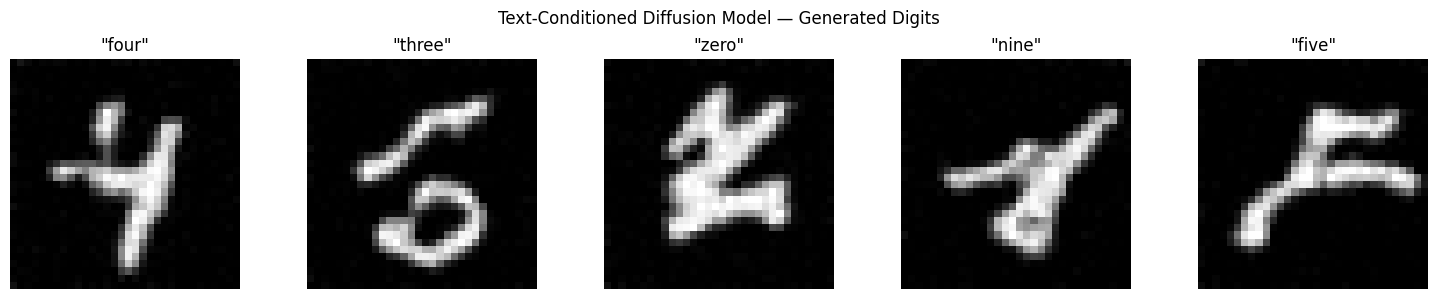

In [15]:

# ---------------------------------------------------------------------------
# 10. Visualization: generate and plot a few test names
# ---------------------------------------------------------------------------
test_names = ["four", "three", "zero", "nine", "five"]

fig, axes = plt.subplots(1, len(test_names), figsize=(3 * len(test_names), 3))
for ax, name in zip(axes, test_names):
    img = generate_image_from_name(name)
    ax.imshow(img, cmap="gray")
    ax.set_title(f'"{name}"')
    ax.axis("off")

plt.suptitle("Text-Conditioned Diffusion Model — Generated Digits")
plt.tight_layout()
plt.show()